!git clone -b dev-sys-reorganizing https://github.com/alx87grd/minilink
import sys
sys.path.append('/content/minilink')
!pip install meshcat

In [34]:
%matplotlib inline
# Colab-friendly: use `sys.animate(renderer="matplotlib", html=True)` in the Animation section.
# Pygame and `sys.game()` need a local display / keyboard; those calls are commented out below.

# !git clone https://github.com/alx87grd/minilink
# import sys
# sys.path.append('/content/minilink')


In [35]:
import numpy as np

from minilink.core.diagram import DiagramSystem
from minilink.core.framework import DynamicSystem, StaticSystem

In [36]:
from minilink.blocks.examples import Pendulum, PendulumPDController
from minilink.blocks.sources import Step, WhiteNoise

# Diagram Creation

## Subsystem definitions

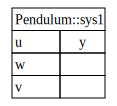

In [37]:
# Plant system
sys = Pendulum()
sys.params["m"] = 1.0
sys.params["l"] = 5.0
sys.x0[0] = 2.0

sys

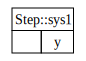

In [38]:
# Source input
step = Step()
step.params["initial_value"] = np.array([0.0])
step.params["final_value"] = np.array([1.0])
step.params["step_time"] = 10.0

step

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'Step signal'}, xlabel='time [s]', ylabel='value'>)

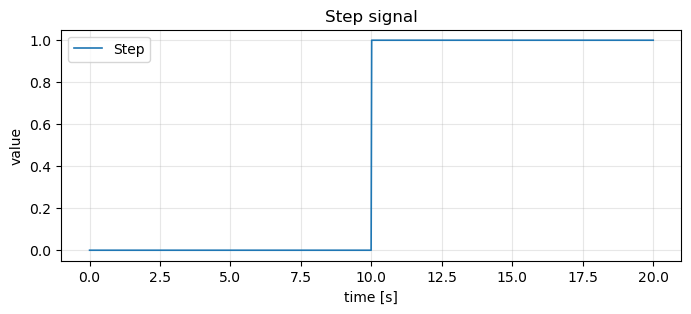

In [39]:
step.show_signal(t0=0.0, tf=20.0)

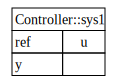

In [40]:
# Closed loop system
ctl = PendulumPDController()
ctl.params["Kp"] = 1000.0
ctl.params["Kd"] = 100.0
ctl

## Creating the diagram

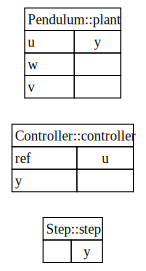

In [41]:
# Diagram
diagram = DiagramSystem()

diagram.add_subsystem(step, "step")
diagram.add_subsystem(ctl, "controller")
diagram.add_subsystem(sys, "plant")

diagram

Simulator:
--------------
Simulating system Diagram from t=0 to t=20
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 200001, dt=0.0001 and solver= scipy


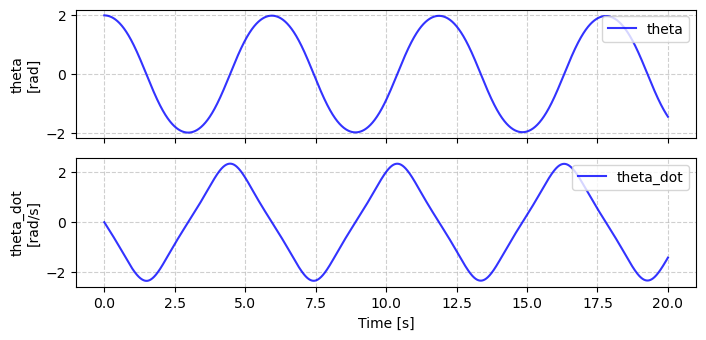

Trajectory(t=array([0.00000e+00, 1.00000e-04, 2.00000e-04, ..., 1.99998e+01,
       1.99999e+01, 2.00000e+01], shape=(200001,)), x=array([[ 2.00000000e+00,  1.99999999e+00,  1.99999996e+00, ...,
        -1.45226794e+00, -1.45241020e+00, -1.45255245e+00],
       [ 0.00000000e+00, -1.78404155e-04, -3.56808312e-04, ...,
        -1.42275484e+00, -1.42256001e+00, -1.42236518e+00]],
      shape=(2, 200001)), u=array([], shape=(0, 200001), dtype=float64), signals=mappingproxy({}))

In [42]:
diagram.compute_trajectory(tf=20, show=True)

Connected step:y to controller:ref


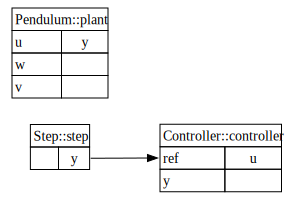

In [43]:
diagram.connect("step", "y", "controller", "ref")
diagram

Connected controller:u to plant:u


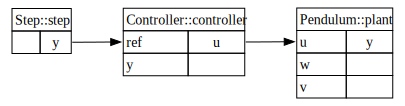

In [44]:
diagram.connect("controller", "u", "plant", "u")
diagram

Simulator:
--------------
Simulating system Diagram from t=0 to t=20
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 200001, dt=0.0001 and solver= scipy


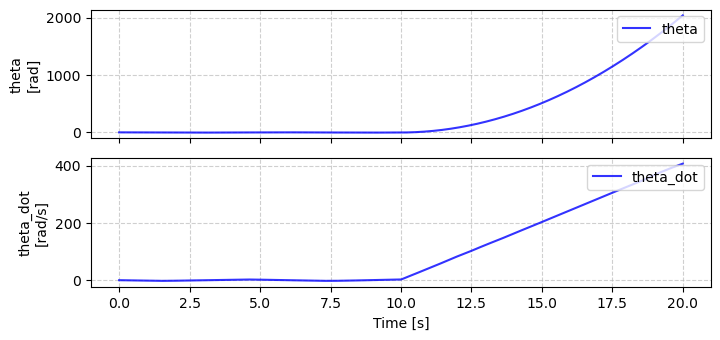

Trajectory(t=array([0.00000e+00, 1.00000e-04, 2.00000e-04, ..., 1.99998e+01,
       1.99999e+01, 2.00000e+01], shape=(200001,)), x=array([[ 2.00000000e+00,  1.99999999e+00,  1.99999996e+00, ...,
         2.03679268e+03,  2.03683332e+03,  2.03687397e+03],
       [ 0.00000000e+00, -1.78404155e-04, -3.56808312e-04, ...,
         4.06448998e+02,  4.06452820e+02,  4.06456643e+02]],
      shape=(2, 200001)), u=array([], shape=(0, 200001), dtype=float64), signals=mappingproxy({}))

In [45]:
diagram.compute_trajectory(tf=20)

Connected plant:y to controller:y


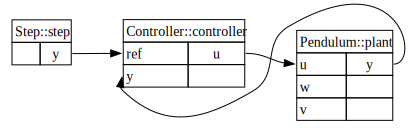

In [46]:
diagram.connect("plant", "y", "controller", "y")
diagram

Simulator:
--------------
Simulating system Diagram from t=0 to t=20
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 200001, dt=0.0001 and solver= scipy


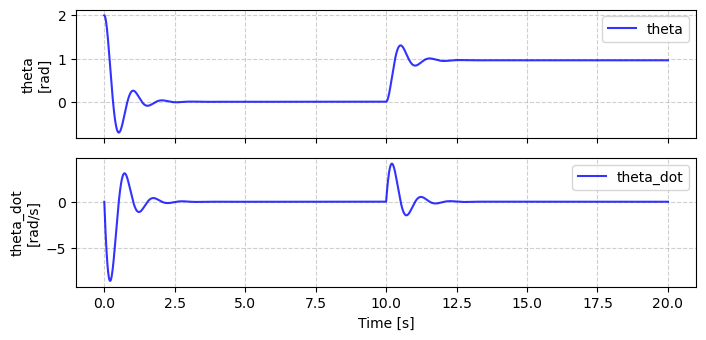

Trajectory(t=array([0.00000e+00, 1.00000e-04, 2.00000e-04, ..., 1.99998e+01,
       1.99999e+01, 2.00000e+01], shape=(200001,)), x=array([[ 2.00000000e+00,  1.99999959e+00,  1.99999836e+00, ...,
         9.59823728e-01,  9.59823728e-01,  9.59823728e-01],
       [ 0.00000000e+00, -8.17676816e-03, -1.63502631e-02, ...,
        -1.03632252e-07, -1.04049503e-07, -1.04466468e-07]],
      shape=(2, 200001)), u=array([], shape=(0, 200001), dtype=float64), signals=mappingproxy({}))

In [47]:
diagram.compute_trajectory(tf=20)

# Custom sys

In [48]:
class Integrator(DynamicSystem):
    def __init__(self):

        super().__init__(1, 1, 1)
        self.name = "Integrator"
        self.outputs = {}
        self.add_output_port(1, "y", function=self.h, dependencies=[])

    def f(self, x, u, t=0, params=None):

        dx = np.zeros(self.n)
        dx[0] = u[0]

        return dx

    def h(self, x, u, t=0, params=None):

        y = np.zeros(self.p)
        y[0] = x[0]

        return y

In [49]:
class PropController(StaticSystem):
    def __init__(self):
        super().__init__(2, 1)

        self.params = {
            "Kp": 10.0,
        }

        self.name = "Controller"

        self.inputs = {}
        self.add_input_port(1, "ref", nominal_value=np.array([0.0]))
        self.add_input_port(1, "y", nominal_value=np.array([0.0]))

        self.outputs = {}
        self.add_output_port(1, "u", function=self.ctl, dependencies=["ref", "y"])

    ######################################################################
    def ctl(self, x, u, t=0, params=None):

        if params is None:
            params = self.params

        Kp = params["Kp"]

        r = u[0]
        y = u[1]

        u = Kp * (r - y)

        u = np.array([u])

        return u

Connected integrator1:y to integrator2:u
Connected controller2:u to integrator1:u
Connected integrator1:y to controller2:y
Connected controller1:u to controller2:ref
Connected integrator2:y to controller1:y
Connected step:y to controller1:ref


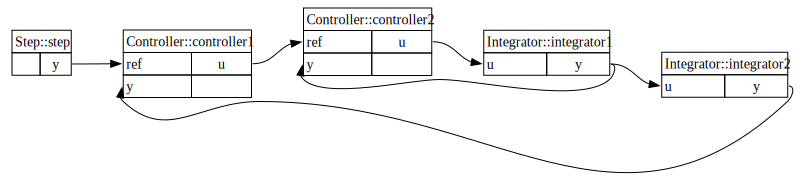

In [50]:
## Cascade controller diagram

# Plant system
sys1 = Integrator()
sys1.state.labels = ["v"]
sys1.x0[0] = 20.0
sys2 = Integrator()
sys2.state.labels = ["x"]
sys2.x0[0] = 20.0

# Controllers
ctl1 = PropController()
ctl1.params["Kp"] = 1.0
ctl2 = PropController()
ctl2.params["Kp"] = 1.0

# Source input
step = Step()
step.params["initial_value"] = np.array([0.0])
step.params["final_value"] = np.array([1.0])
step.params["step_time"] = 10.0

# # Diagram
diagram = DiagramSystem()

diagram.add_subsystem(step, "step")
diagram.add_subsystem(ctl1, "controller1")
diagram.add_subsystem(ctl2, "controller2")
diagram.add_subsystem(sys1, "integrator1")
diagram.add_subsystem(sys2, "integrator2")

diagram.connect("integrator1", "y", "integrator2", "u")
diagram.connect("controller2", "u", "integrator1", "u")
diagram.connect("integrator1", "y", "controller2", "y")
diagram.connect("controller1", "u", "controller2", "ref")
diagram.connect("integrator2", "y", "controller1", "y")
diagram.connect("step", "y", "controller1", "ref")
diagram

Simulator:
--------------
Simulating system Diagram from t=0 to t=10
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 100001, dt=0.0001 and solver= scipy


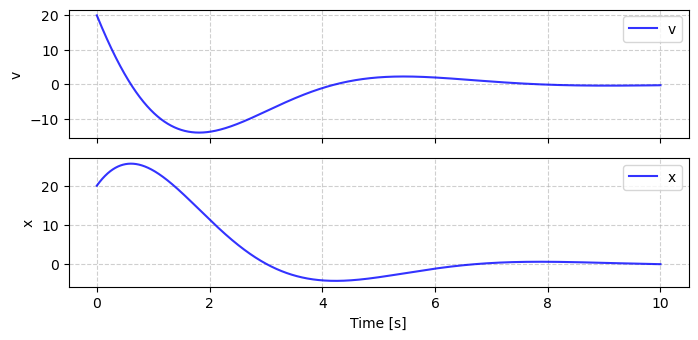

In [51]:
traj = diagram.compute_trajectory()

# Noise ports exemple

Connected step:y to controller:ref
Connected controller:u to plant:u
Connected plant:y to controller:y
Connected noise:y to plant:w
Connected noise2:y to plant:v


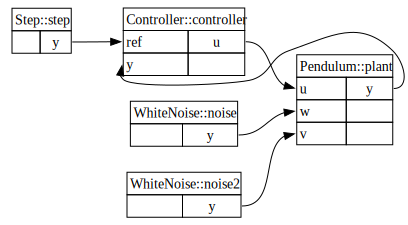

In [52]:
# Plant system
sys = Pendulum()

sys.params["m"] = 1.0
sys.params["l"] = 5.0

sys.x0[0] = 2.0

# Source input
step = Step()
step.params["initial_value"] = np.array([0.0])
step.params["final_value"] = np.array([1.0])
step.params["step_time"] = 10.0

# Noisy input
noise = WhiteNoise(1)
noise.params["var"] = 1.0
noise.params["mean"] = 0.0
noise.params["seed"] = 1

# Noisy measurement
noise2 = WhiteNoise(1)
noise2.params["var"] = 0.1
noise2.params["mean"] = 0.0
noise2.params["seed"] = 2

# Closed loop system
ctl = PendulumPDController()
ctl.params["Kp"] = 1000.0
ctl.params["Kd"] = 100.0

# Diagram
diagram2 = DiagramSystem()

diagram2.add_subsystem(step, "step")
diagram2.add_subsystem(ctl, "controller")
diagram2.add_subsystem(sys, "plant")
diagram2.add_subsystem(noise, "noise")
diagram2.add_subsystem(noise2, "noise2")

diagram2.connect("step", "y", "controller", "ref")
diagram2.connect("controller", "u", "plant", "u")
diagram2.connect("plant", "y", "controller", "y")
diagram2.connect("noise", "y", "plant", "w")
diagram2.connect("noise2", "y", "plant", "v")
diagram2

(<Figure size 800x300 with 1 Axes>,
 <Axes: title={'center': 'WhiteNoise signal'}, xlabel='time [s]', ylabel='value'>)

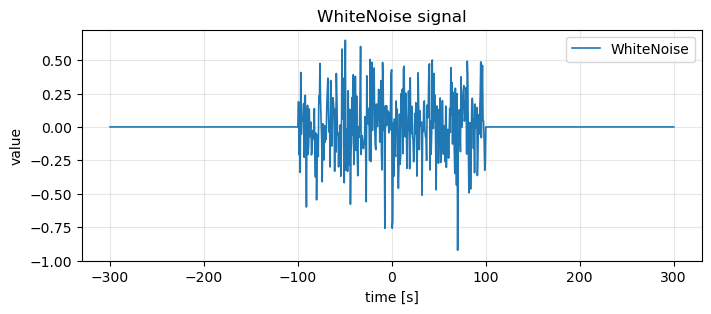

In [53]:
noise2.show_signal(t0=-300.0, tf=300.0)

In [54]:
noise2.params

{'var': 0.1,
 'mean': 0.0,
 'seed': 2,
 'sample_period': 0.01,
 't0': -100.0,
 'tf': 100.0}

Simulator:
--------------
Simulating system Diagram from t=0 to t=10
Auto-compiling backend=numpy.
Time steps = 1001, dt=0.01 and solver= euler


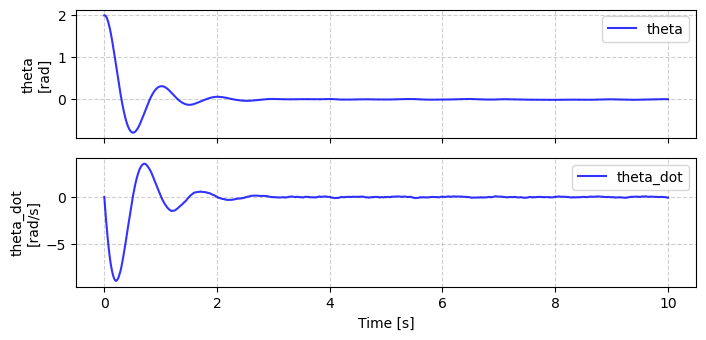

Trajectory(t=array([ 0.  ,  0.01,  0.02, ...,  9.98,  9.99, 10.  ], shape=(1001,)), x=array([[ 2.        ,  2.        ,  1.99194449, ...,  0.00593816,
         0.00537812,  0.00474629],
       [ 0.        , -0.80555069, -1.59712464, ..., -0.05600382,
        -0.06318276, -0.05944893]], shape=(2, 1001)), u=array([], shape=(0, 1001), dtype=float64), signals=mappingproxy({}))

In [55]:
diagram2.compute_trajectory(
    solver="euler", dt=0.01
)  # White noise is not a continuous system.. and scipy does not like it..

In [56]:
traj = diagram2.compute_trajectory(show=False) 

Simulator:
--------------
Simulating system Diagram from t=0 to t=10
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 100001, dt=0.0001 and solver= scipy


Simulator:
--------------
Simulating system Diagram from t=0 to t=10
Auto-compiling backend=numpy.
Time steps = 1001, dt=0.01 and solver= euler


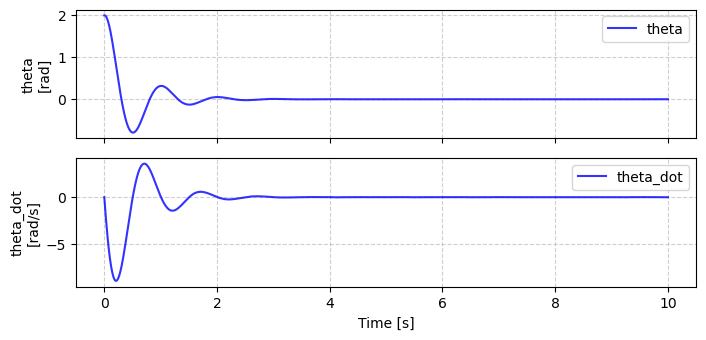

Trajectory(t=array([ 0.  ,  0.01,  0.02, ...,  9.98,  9.99, 10.  ], shape=(1001,)), x=array([[ 2.00000000e+00,  2.00000000e+00,  1.99183404e+00, ...,
         5.84724979e-04,  5.28475312e-04,  4.65248625e-04],
       [ 0.00000000e+00, -8.16595534e-01, -1.60234336e+00, ...,
        -5.62496679e-03, -6.32266863e-03, -5.92866064e-03]],
      shape=(2, 1001)), u=array([], shape=(0, 1001), dtype=float64), signals=mappingproxy({}))

In [57]:
diagram2.subsystems["noise"].params["var"] = 0.001
diagram2.subsystems["noise2"].params["var"] = 0.001
diagram2.compute_trajectory(solver="euler", dt=0.01)

Simulator:
--------------
Simulating system Diagram from t=0 to t=10
Auto-compiling backend=numpy.
Time steps = 1001, dt=0.01 and solver= euler


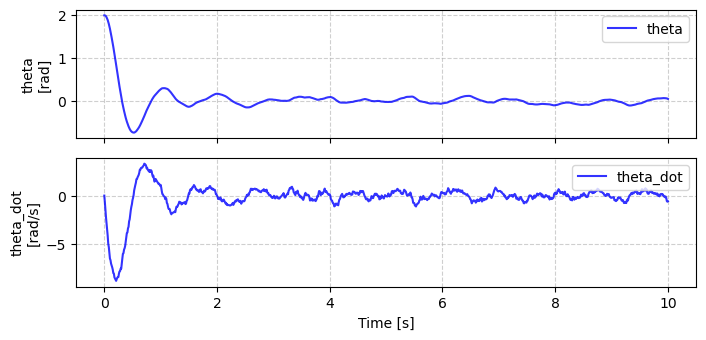

Trajectory(t=array([ 0.  ,  0.01,  0.02, ...,  9.98,  9.99, 10.  ], shape=(1001,)), x=array([[ 2.        ,  2.        ,  1.99306648, ...,  0.05847311,
         0.05284834,  0.04652587],
       [ 0.        , -0.69335222, -1.54058183, ..., -0.56247664,
        -0.63224723, -0.59284707]], shape=(2, 1001)), u=array([], shape=(0, 1001), dtype=float64), signals=mappingproxy({}))

In [58]:
diagram2.subsystems["noise"].params["var"] = 10.0
diagram2.subsystems["noise2"].params["var"] = 10.0
diagram2.compute_trajectory(solver="euler", dt=0.01)

# Animation tools

On **Colab**, use `renderer="matplotlib"` with `html=True` for embedded video. Pygame and most meshcat flows need a local machine (see comments in the next cells).


In [59]:
# Plant system
sys = Pendulum()

sys.params["m"] = 1.0
sys.params["l"] = 5.0

sys.x0[0] = 2.0
sys.compute_trajectory(tf=20.0, dt=0.01, show=False)

Simulator:
--------------
Simulating system Pendulum from t=0 to t=20.0
Auto-compiling backend=numpy.
Time steps = 2002, dt=0.01 and solver= scipy


Trajectory(t=array([0.000e+00, 1.000e-02, 2.000e-02, ..., 1.999e+01, 2.000e+01,
       2.001e+01], shape=(2002,)), x=array([[ 2.        ,  1.9999108 ,  1.99964318, ..., -1.43822787,
        -1.4525485 , -1.4666738 ],
       [ 0.        , -0.01784066, -0.03568277, ..., -1.44174453,
        -1.42226207, -1.40275739]], shape=(2, 2002)), u=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(3, 2002)), signals=mappingproxy({}))

In [60]:
# Not for Colab: pygame needs a local window.
# sys.animate(renderer="pygame")
# Matplotlib + html=True returns an inline FuncAnimation via to_jshtml().
# html=None (default) auto-detects Colab and flips to html=True there.
sys.animate(renderer="matplotlib", html=True)


pygame 2.6.1 (SDL 2.32.56, Python 3.13.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


### Native meshcat animation in Colab

`sys.animate(renderer="meshcat", html=True, native=True)` builds a `meshcat.animation.Animation` and embeds the scene as a self-contained `static_html` iframe, which is what you want for Colab (no zmq client, no port forwarding). Dynamic-geometry primitives such as `TorqueArrow` are frozen at `t=0` on this path by design (see `DESIGN.md` §4.7) — use `native=False` for frame-accurate playback of those primitives locally.


In [ ]:
# Meshcat native animation, rendered inline via static_html iframe.
# html=True forces the inline path even outside Colab.
sys.animate(renderer="meshcat", html=True, native=True)


On a **local machine** you can try `sys.animate(renderer="meshcat")` or `renderer="pygame"` after `compute_trajectory` (same `sys` as the cell above).


Re-run the matplotlib cell after changing the plant or trajectory to refresh the inline animation.


# Interactive mode

`sys.game()` depends on **pygame** (keyboard / display) and is **not** suitable for Colab. The code cells below are no-ops or use `animate(..., matplotlib, html=True)` instead.


In [63]:
# Plant system
sys = Pendulum()

sys.params["m"] = 1.0
sys.params["l"] = 5.0

In [64]:
# Interactive `game()` uses pygame for keyboard input even with meshcat — skip on Colab.
# sys.game(renderer="meshcat")
# sys.game(renderer="pygame")
pass  # no-op on Colab; use `animate(..., renderer="matplotlib", html=True)` above


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7011/static/


In [65]:
# sys.game(renderer="pygame")
# (see cell above — game() is disabled for Colab)


In [66]:
from minilink.blocks.dynamic_bicycle import DynamicBicycleCar3D

sys = DynamicBicycleCar3D()
# sys.game(renderer="meshcat")  # requires pygame + realtime; not Colab
sys.compute_trajectory(tf=5.0, show=False)
sys.animate(renderer="matplotlib", html=True)


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7012/static/


# Compilation to jax

In [67]:
import time

import numpy as np

from minilink.core.diagram import DiagramSystem
from minilink.core.framework import System

try:
    import jax.numpy as jnp

    JAX_AVAILABLE = True
except ImportError:
    JAX_AVAILABLE = False


class SimpleGain(System):
    def __init__(self, id_str, gain=2.0):
        super().__init__(0, 1, 1)
        self.name = id_str
        self.gain = gain
        self.add_input_port(1, "u")
        self.add_output_port(1, "y", function=self.h, dependencies=["u"])

    def h(self, x, u, t=0, params=None):
        return u * self.gain


class SimpleIntegrator(System):
    def __init__(self, id_str):
        super().__init__(1, 1, 1)
        self.name = id_str
        self.add_input_port(1, "u")
        self.add_output_port(1, "x", function=self.compute_state, dependencies="")

    def compute_state(self, x, u, t=0, params=None):
        return x

    def f(self, x, u, t=0, params=None):
        return u * u * u

In [68]:
sys = SimpleIntegrator('aaa')
sys.f(11,2,0)


8

In [69]:
eval = sys.compile(backend="jax")
eval.f

<bound method JaxLeafEvaluator.f of <minilink.compile.jax_evaluator.JaxLeafEvaluator object at 0x1065ffd90>>

In [70]:
class MultiInputNode(System):
    def __init__(self, id_str, in_ports):
        super().__init__(1, in_ports, 1)
        self.name = id_str
        self.in_ports = in_ports
        for p in range(in_ports):
            self.add_input_port(1, f"u{p}")
        self.add_output_port(1, "x", function=self.compute_state, dependencies="all")

    def compute_state(self, x, u, t=0, params=None):
        return x

    def f(self, x, u, t=0, params=None):
        return u.sum()


def build_dense_network(num_nodes=50, connections_per_node=3):
    """Builds a dense feed-forward network of nodes."""
    diag = DiagramSystem()
    diag.graphe_building_verbose = False
    for i in range(num_nodes):
        diag.add_subsystem(SimpleIntegrator(f"Integrator{i}"), f"Node{i}")

    np.random.seed(42)
    for i in range(1, num_nodes):
        num_conn = min(i, connections_per_node)
        sources = np.random.choice(range(i), size=num_conn, replace=False)

        sys_id = f"MultiNode{i}"
        diag.add_subsystem(MultiInputNode(sys_id, num_conn), sys_id)

        for p_idx, src_i in enumerate(sources):
            diag.connect(f"Node{src_i}", "x", sys_id, f"u{p_idx}")

        diag.connect(sys_id, "x", f"Node{i}", "u")

    diag.add_subsystem(SimpleGain("SourceNode"), "SourceNode")
    diag.connect("SourceNode", "y", "Node0", "u")
    return diag


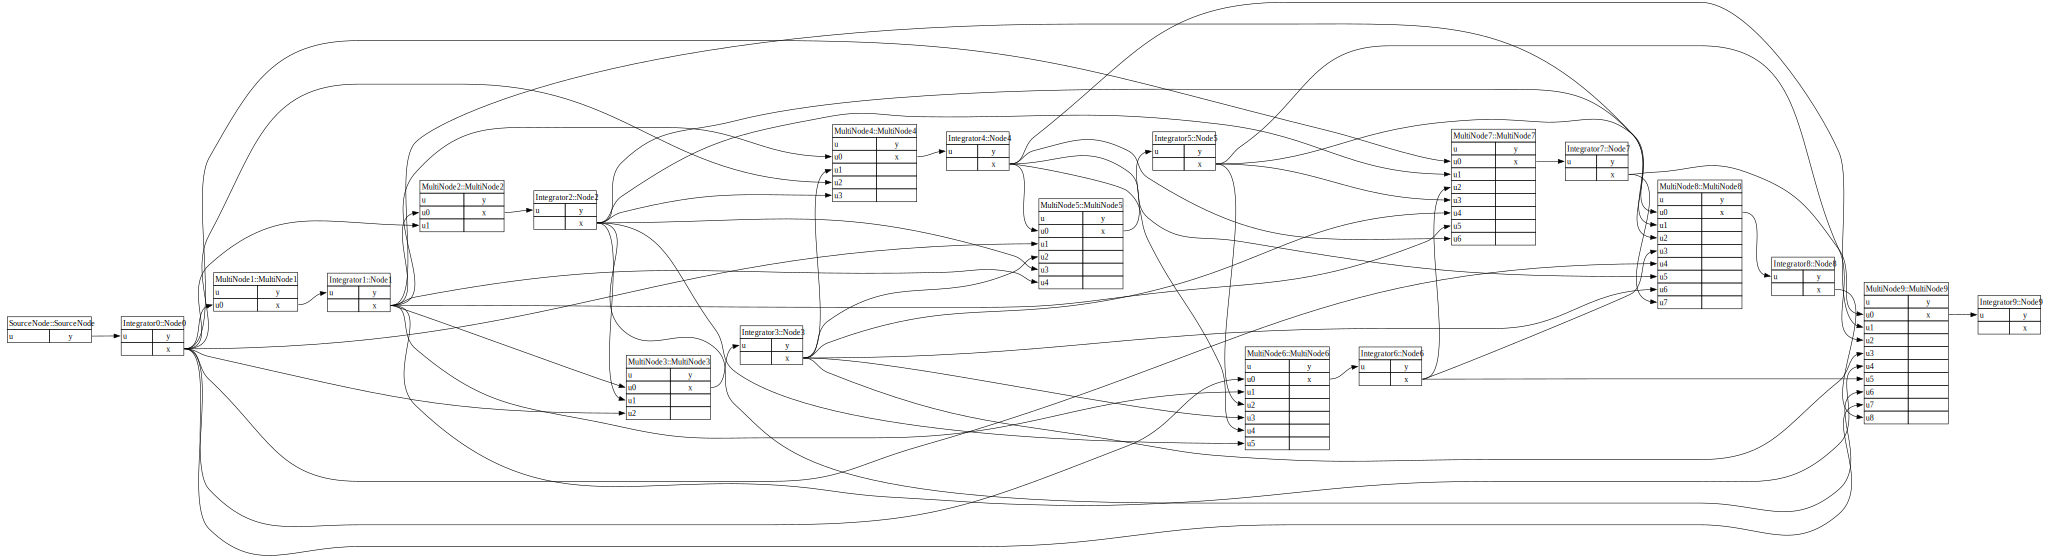

In [71]:
diag = build_dense_network(num_nodes=10, connections_per_node=10)
diag
# diag.plot_graphe()

In [72]:
diag.n

19

In [73]:
# diag.compute_trajectory(tf=20.0)
np_eval = diag.compile(backend="numpy", verbose=True)


[compile] Step 1: Checking for algebraic loops...  (0.000s)
[compile] Step 2: Building execution plan (39 ports, 19 states)...  (0.000s)
[compile] Done.  (0.001s total)


In [74]:
eval_jax = diag.compile(backend="jax", verbose=True)

[compile] Step 1: Checking for algebraic loops...  (0.000s)
[compile] Step 2: Building execution plan (39 ports, 19 states)...  (0.000s)
[compile] Step 0: Checking JAX compatibility of 20 blocks...  (0.013s)
[compile] Step 3: JIT-compiling to XLA on cpu...  (0.000s)
[compile] Step 4: Warm-starting JIT cache...  (0.262s)
[compile] Done.  (0.277s total)


In [75]:

n_iters = 1000
print(f"\nBenchmarking {n_iters} iterations:")

f_python = diag.f
f_numpy = np_eval.f
f_jax = eval_jax.f

x = np.random.randn(diag.n)
u = np.random.randn(diag.m)

# Baseline (recursive)
t0 = time.perf_counter()
for _ in range(n_iters):
    f_python(x, u)
dt = time.perf_counter() - t0
print(f"Baseline:       {dt:.4f} s ({n_iters/dt:.0f} evals/sec)")

# NumPy Compiled
t0 = time.perf_counter()
for _ in range(n_iters):
    f_numpy(x, u)
dt = time.perf_counter() - t0
print(f"NumPy Compiled: {dt:.4f} s ({n_iters/dt:.0f} evals/sec)")



t0 = time.perf_counter()
for _ in range(n_iters):
    f_jax(x, u).block_until_ready()
dt = time.perf_counter() - t0
print(f"JAX JIT:        {dt:.4f} s ({n_iters/dt:.0f} evals/sec)")



Benchmarking 1000 iterations:
Baseline:       0.1094 s (9138 evals/sec)
NumPy Compiled: 0.0640 s (15618 evals/sec)
JAX JIT:        0.0084 s (119046 evals/sec)


# Symbolic

In [76]:
from minilink.mechanics.symbolic import MechanicalModel

# ------------------------------------------------------------------
# Build the symbolic model
# ------------------------------------------------------------------
m = MechanicalModel("QuadruplePendulum")
N_LINKS = 4

lengths, com_offsets, masses, inertias = [], [], [], []
for i in range(1, N_LINKS + 1):
    li, lci = m.parameters(f"l{i} lc{i}")
    mi = m.parameters(f"m{i}")
    Ii = m.parameters(f"I{i}")
    lengths.append(li)
    com_offsets.append(lci)
    masses.append(mi)
    inertias.append(Ii)

g_sym = m.parameters("g")

coord_names = " ".join(f"q{i}" for i in range(1, N_LINKS + 1))
coords = m.coordinates(coord_names)

dh_table = [
    {"theta": coords[i], "d": 0, "a": lengths[i], "alpha": 0} for i in range(N_LINKS)
]
link_properties = [
    {
        "mass": masses[i],
        "inertia": {"Izz": inertias[i]},
        "com_offset": com_offsets[i],
    }
    for i in range(N_LINKS)
]

m.add_dh_chain(dh_table, link_properties)
m.add_gravity(-g_sym * m.N.y)

# ------------------------------------------------------------------
# Derive the symbolic equations of motion
# -----------------------------------------------------------------
print("Deriving the symbolic equations of motion...")

sym_sys = m.derive(method="lagrange", simplify=True)

Deriving the symbolic equations of motion...


In [77]:
sym_sys.H

Matrix([
[I1 + I2 + I3 + I4 + lc1**2*m1 + m2*(l1**2 + 2*l1*lc2*cos(q2(t)) + lc2**2) + m3*(l1**2 + 2*l1*l2*cos(q2(t)) + 2*l1*lc3*cos(q2(t) + q3(t)) + l2**2 + 2*l2*lc3*cos(q3(t)) + lc3**2) + m4*(l1**2 + 2*l1*l2*cos(q2(t)) + 2*l1*l3*cos(q2(t) + q3(t)) + 2*l1*lc4*cos(q2(t) + q3(t) + q4(t)) + l2**2 + 2*l2*l3*cos(q3(t)) + 2*l2*lc4*cos(q3(t) + q4(t)) + l3**2 + 2*l3*lc4*cos(q4(t)) + lc4**2), I2 + I3 + I4 + lc2*m2*(l1*cos(q2(t)) + lc2) + m3*(l1*l2*cos(q2(t)) + l1*lc3*cos(q2(t) + q3(t)) + l2**2 + 2*l2*lc3*cos(q3(t)) + lc3**2) + m4*(l1*l2*cos(q2(t)) + l1*l3*cos(q2(t) + q3(t)) + l1*lc4*cos(q2(t) + q3(t) + q4(t)) + l2**2 + 2*l2*l3*cos(q3(t)) + 2*l2*lc4*cos(q3(t) + q4(t)) + l3**2 + 2*l3*lc4*cos(q4(t)) + lc4**2), I3 + I4 + lc3*m3*(l1*cos(q2(t) + q3(t)) + l2*cos(q3(t)) + lc3) + m4*(l1*l3*cos(q2(t) + q3(t)) + l1*lc4*cos(q2(t) + q3(t) + q4(t)) + l2*l3*cos(q3(t)) + l2*lc4*cos(q3(t) + q4(t)) + l3**2 + 2*l3*lc4*cos(q4(t)) + lc4**2), I4 + lc4*m4*(l1*cos(q2(t) + q3(t) + q4(t)) + l2*cos(q3(t) + q4(t)) + l3*co

In [78]:
sym_sys.g

Matrix([
[g*lc1*m1*cos(q1(t)) + g*m2*(l1*cos(q1(t)) + lc2*cos(q1(t) + q2(t))) + g*m3*(l1*cos(q1(t)) + l2*cos(q1(t) + q2(t)) + lc3*cos(q1(t) + q2(t) + q3(t))) - m4*(-g*l1*cos(q1(t)) - g*l2*cos(q1(t) + q2(t)) - g*l3*cos(q1(t) + q2(t) + q3(t)) - g*lc4*cos(q1(t) + q2(t) + q3(t) + q4(t)))],
[                                                                          g*lc2*m2*cos(q1(t) + q2(t)) + g*m3*(l2*cos(q1(t) + q2(t)) + lc3*cos(q1(t) + q2(t) + q3(t))) - m4*(-g*l2*cos(q1(t) + q2(t)) - g*l3*cos(q1(t) + q2(t) + q3(t)) - g*lc4*cos(q1(t) + q2(t) + q3(t) + q4(t)))],
[                                                                                                                                                            g*lc3*m3*cos(q1(t) + q2(t) + q3(t)) - m4*(-g*l3*cos(q1(t) + q2(t) + q3(t)) - g*lc4*cos(q1(t) + q2(t) + q3(t) + q4(t)))],
[                                                                                                                                                            

### exporting to minlink  sys

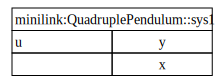

In [79]:
params = {}
for i in range(N_LINKS):
    params[lengths[i]] = 1.5
    params[com_offsets[i]] = 1.5
    params[masses[i]] = 10.0
    params[inertias[i]] = 0.1
params[g_sym] = 9.81

sys = sym_sys.to_minilink(parameters=params, backend="jax")

sys

Simulator:
--------------
Simulating system minilink:QuadruplePendulum from t=0 to t=10.0
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 100001, dt=0.0001 and solver= scipy


/Users/agirard/code/minilink/minilink/mechanics/symbolic/export.py:57: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  flat_arr = jnp.asarray(out, dtype=jnp.float64).reshape(-1)
/Users/agirard/code/minilink/minilink/mechanics/mechanical.py:242: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  [jnp.asarray(q, dtype=dt).ravel(), jnp.asarray(dq, dtype=dt).ravel()]


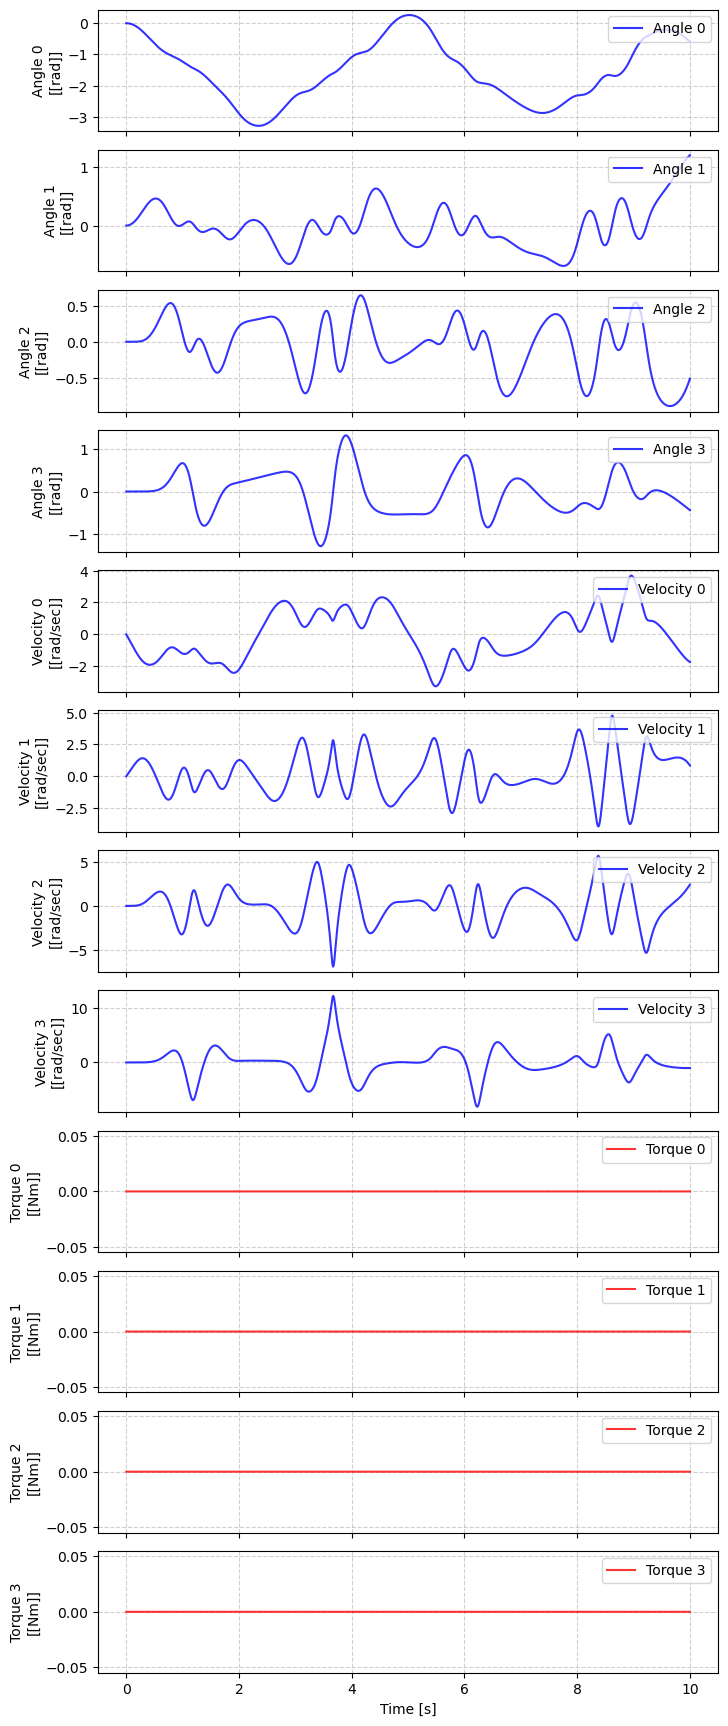

Trajectory(t=array([0.0000e+00, 1.0000e-04, 2.0000e-04, ..., 9.9998e+00, 9.9999e+00,
       1.0000e+01], shape=(100001,)), x=array([[ 0.00000000e+00, -3.25559021e-08, -1.30223608e-07, ...,
        -5.91525475e-01, -5.91699239e-01, -5.91873026e-01],
       [ 0.00000000e+00,  3.24124113e-08,  1.29649642e-07, ...,
         1.19510242e+00,  1.19518698e+00,  1.19527147e+00],
       [ 0.00000000e+00,  1.42884686e-10,  5.71538764e-10, ...,
        -5.09107937e-01, -5.08864775e-01, -5.08621514e-01],
       ...,
       [ 0.00000000e+00,  6.48248243e-04,  1.29649649e-03, ...,
         8.45897784e-01,  8.45233939e-01,  8.44569660e-01],
       [ 0.00000000e+00,  2.85769384e-06,  5.71538769e-06, ...,
         2.43113802e+00,  2.43212261e+00,  2.43310739e+00],
       [ 0.00000000e+00,  1.19351396e-08,  2.38702793e-08, ...,
        -1.02321838e+00, -1.02316374e+00, -1.02310898e+00]],
      shape=(8, 100001)), u=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0.

In [80]:
sys.compute_trajectory(tf=10.0)

In [81]:
# sys.animate(renderer="pygame")
# sys.animate(renderer="meshcat")
sys.animate(renderer="matplotlib", html=True)


You can open the visualizer by visiting the following URL:
http://127.0.0.1:7013/static/


# Engine

In [82]:
from minilink.physics import PhysicsWorldSystem
from minilink.physics.engine_jax import PlaneModel, SphereModel, make_world_model

# 10x larger scene than the 12-sphere MVP: 12x10 grid = 120 spheres.
nx, ny = 12, 10
n_spheres = nx * ny

# Smooth radius/mass variation for visual diversity.
radii = np.linspace(0.18, 0.35, n_spheres)
masses = np.linspace(0.6, 1.8, n_spheres)
specs = list(zip(radii, masses))
spheres = [SphereModel(mass=m, radius=r) for (r, m) in specs]

# XY layout and varied Z heights.
x_vals = np.linspace(-6.0, 6.0, nx)
y_vals = np.linspace(-4.5, 4.5, ny)
xy_grid = [(x, y) for y in y_vals for x in x_vals]
z_heights = np.linspace(1.0, 6.0, n_spheres)

world = make_world_model(
    spheres,
    PlaneModel(normal=(0.0, 0.0, 1.0), offset=0.0),
    gravity=(0.0, 0.0, -9.81),
    k_contact=1000.0,
    c_contact=1.0,
)

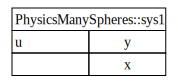

In [83]:
sys = PhysicsWorldSystem(world, name="PhysicsManySpheres")

# State layout per body: [p(3), q(4), v(3), w(3)].
x0 = np.zeros(sys.n)
for i in range(sys.world.n_bodies):
    base = 13 * i
    x, y = xy_grid[i]
    z = z_heights[i]
    x0[base : base + 3] = [x, y, z]
    x0[base + 3 : base + 7] = [1.0, 0.0, 0.0, 0.0]  # unit quaternion
sys.x0 = x0

sys


In [84]:
sys.compute_trajectory(tf=10.0, show=False, solver="scipy")
# sys.animate(renderer="meshcat")
sys.animate(renderer="matplotlib", html=True)


Simulator:
--------------
Simulating system PhysicsManySpheres from t=0 to t=10.0
Automatic dt based on the smallest time constant of the system
Auto-compiling backend=numpy.
Time steps = 100001, dt=0.0001 and solver= scipy
You can open the visualizer by visiting the following URL:
http://127.0.0.1:7014/static/


### Engine is jax compatible

In [85]:
x = np.random.randn(sys.n)
u = np.random.randn(sys.m)

evaluator = sys.compile(backend="jax", verbose=True)

n_iter = 1000
t0 = time.perf_counter()
for _ in range(n_iter):
    sys.f(x, u, 0.0)
t_pure = time.perf_counter() - t0

t0 = time.perf_counter()
for _ in range(n_iter):
    evaluator.f(x, u, 0.0)
t_compiled = time.perf_counter() - t0

print(
    f"Speed ({n_iter} calls): \n"
    f"sys.f (native python):   {1e6 * t_pure / n_iter:.1f} us/call,\n"
    f"evaluator.f (jax jit):   {1e6 * t_compiled / n_iter:.1f} us/call, "
)


[compile] Step 0: Checking JAX compatibility of 'PhysicsManySpheres'...  (0.008s)
[compile] Step 1: JIT-compiling to XLA on cpu...  (0.001s)
[compile] Step 2: Warm-starting JIT cache...  (0.146s)
[compile] Done.  (0.156s total)
Speed (1000 calls): 
sys.f (native python):   1501.6 us/call,
evaluator.f (jax jit):   11.4 us/call, 


### Not only faster but auto-diff compatible

In [86]:
import jax
u = np.zeros(sys.m)
t=0.0

fx = lambda x: evaluator.f(x, u, t)

df_dx_func = jax.jacfwd(fx)

x = np.random.randn(sys.n)
df_dx = df_dx_func(x)

df_dx





Array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)